In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

# 3) Calcul à l'aide de la méthode de Monte-Carlo 

On appelle méthode de Monte-Carlo toute méthode utilisant des résultats/techniques probabilistes pour obtenir une approximation d'une valeur numérique. Grosso modo, dans nos contextes, c'est surtout quand on utilise la loi des grands nombres pour approcher une espérance (qui peut représenter une certaine proba, ou alors une intégrale qui nous intéresse ou autre). 

## 3.1) Approximation de probabilités 

Si $X$ est une variable aléatoire réelle, et $B$ un certain borélien dont on veut approximer la probabilité. On utilise alors la loi des grands nombres pour fabriquer une méthode de Monte-Carlo: la loi des grands nombres nous dit que si $(X_i)_{i \ge 1}$ est une suite de variables iid de même loi que $X$, alors 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \in B} \xrightarrow[n \to \infty]{\text{p.s.}} \mathbb{E}[\mathbb{1}_{X \in B}] = \mathbb{P}(X \in B). $$
Un estimateur (sans biais et fortement consistant) de la probabilité de $B$ est donc donné par 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \in B}. $$

Voyons tout d'abord un exemple bâteau pour s'entraîner: on suppose que $X$ suit une loi normale centrée réduite, et on veut obtenir la probabilité 
$\mathbb{P}(X \ge 0) $ (évidemment, on sait déjà que ça vaut $1/2$, mais il faut bien s'entraîner sur des exemples faciles). On va donc simuler un $n$-échantillon de gaussiennes centrées réduites $(X_i)_{1 \le i \le n}$, et calculer 
$$\frac{1}{n} \sum_{i=1}^n \mathbb{1}_{X_i \ge 0 }. $$

In [5]:
def approx_proba(n): 
    X=stats.norm.rvs(loc=0,scale=1,size=n) 
    return(np.mean(0<=X))

approx_proba(1000) # quelle surprise, on obtient effectivement 0.5 !

np.float64(0.49)

Bon maintenant que l'on a vu un exemple un peu nul pour se mettre en jambes, voyons un vrai exemple utile en pratique. Une situation où il peut être sympa pour un oral de modé d'utiliser la méthode de Monte-Carlo, c'est pour illustrer qu'un intervalle de confiance que l'on vient d'obtenir est effectivement au niveau souhaité. Voyons cela sur un exemple. L'exemple le plus simple d'intervalle de confiance non-asymptotique a lieu pour les gaussiennes (toujours dans les bons plans les gaussiennes) : supposons que $(X_i)_{1 \le i \le n}$ soit un $n$-échantillon de loi $\mathcal N (\mu, \sigma)$ avec $\sigma$ connu et $\mu$ inconnu, pour lequel on veut trouver un intervalle de confiance. On a: 
$$ \frac {\sqrt n}{\sigma}  \left ( \frac{1}{n} \sum_{i=1}^n X_i - \mu \right) \sim \mathcal N (0,1),$$
donc si l'on note $q_{1 - \frac{\alpha}{2}}$ le quantile d'ordre $1 - \frac{\alpha}{2}$ de la loi normale centrée réduite pour un certain niveau $\alpha >0$ que l'on fixe, alors 
$$\mathbb P \left ( \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \le \mu \le \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right) = 1- \alpha. $$
Ainsi, l'intervalle $\displaystyle \left [ \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n }, \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right]$ est un intervalle de confiance non asymptotique pour $\mu$ de niveau de confiance $1-\alpha$. 
Pour montrer fièrement au jury que l'intervalle de confiance que l'on vient de trouver est valide, on peut utiliser la méthode de Monte-Carlo: on simule $N$ échantillons indépendants de taille $n$ suivant la loi $\mathcal N (\mu, \sigma)$, avec $\mu$ connu et fixé en avance que l'on note $(X_i^k)_{1 \le i \le n}$ pour $1 \le k \le N$. Pour chaque échantillon, on calcule les deux bornes de l'intervalle: 
$$ T_{\text{inf}}^k =  \frac{1}{n} \sum_{i=1}^n X_i^k - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \quad \text{et} \quad  T_{\text{sup}}^k =  \frac{1}{n} \sum_{i=1}^n X_i^k + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n },$$
et un estimateur de 
$$ \mathbb P  \left ( \mu \in  \left [ \frac{1}{n} \sum_{i=1}^n X_i - \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n }, \frac{1}{n} \sum_{i=1}^n X_i + \frac{\sigma q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right] \right) $$
est donné par 
$$\frac {1}{N} \sum_{k=1}^N \mathbb{1}_{T_{\text{inf}}^k \le \mu \le T_{\text{sup}}^k}. $$
Plus qu'à le calculer, et à montrer tout fièrement que l'on obtient bien $1 - \alpha$ !

In [7]:
def intervalle_de_conf(mu,sigma,n,N,alpha): #N est le nombre d'échantillons et n est leur taille 
    P=0
    for i in range(0,N):
        X=stats.norm.rvs(loc=mu, scale=sigma,size=n)
        estim=np.mean(X)
        q=stats.norm.ppf(1-alpha/2,loc=0,scale=1)
        c=sigma*q/sqrt(n)
        borne1=estim-c
        borne2=estim+c 
        if borne1 <= mu <= borne2:
            P+=1
    return(P/N)
    
print(intervalle_de_conf(3,1,100,1000,0.05)) # Youhou, ça fonctionne !

0.956


Remarque : si l'intervalle de confiance que vous avez obtenu est un intervalle de confiance ASYMPTOTIQUE, vous pouvez aussi faire cette méthode, et pour $n$ assez grand, ça devrait donner un bon résultat. Un autre moyen d'illustrer un intervalle de confiance asymptotique, c'est de tracer l'estimateur et les bornes de l'intégrale en fonction de $n$ (pour un évènement fixé), à "la convergence p.s.". J'en ai fait un exemple dans la partie suivante. 

## 3.2) Approximation d'intégrales 

Un autre gros fond de commerce des méthodes de Monte-Carlo, c'est de calculer des intégrales, en les écrivant comme des espérances de fonctions de variables aléatoires que l'on sait simuler. Par exemple, supposons que l'on veuille calculer une intégrale de type 
$$I = \int_{\mathbb R^d} g(x) f(x) \mathrm{d} x,$$
telle que 
$$\int_{\mathbb R^d} |g(x)| f(x) \mathrm{d} x < + \infty $$
et où $f$ est une densité de probabilité. On peut estimer $I$ grâce à une méthode de Monte-Carlo qui se base de nouveau sur la loi des grands nombres: on simule un $n$ échantillon $(X_i)_{1 \le i \le n}$ de densité $f$, et un estimateur (sans biais et fortement consistant) de $I$ est donné par : 
$$I_n :=  \frac{1}{n} \sum_{i=1}^n g(X_i), $$
puisque, par la loi des grands nombres
$$I_n \xrightarrow[n \to \infty]{\text{p.s.}} \mathbb E (g(X_1))= I.$$
On peut même faire mieux, et donner un intervalle de confiance asymptotique pour $I$ grâce au théorème central limite. Celui ci nous dit que l'on a la convergence en loi suivante: 
$$\frac{\sqrt n}{\sigma} (I_n - I) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1),$$
avec $\sigma ^2 = \mathbb E [g^2(X)]- \mathbb E [g(X)]$. Or, grâce à la loi des grands nombres, on a 
$$\sigma_n:= \frac{1}{n} \sum_{i=1}^n \left( g(X_i)- I_n \right)^2  \xrightarrow[n \to \infty]{\text{p.s.} } \sigma.$$
Ainsi, par le théorème de Slutsky, on en déduit 
$$\frac{\sqrt n}{\sigma_n} (I_n - I) \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
On en déduit que pour un niveau $\alpha >0$, l'intervalle 
$$\left[ I_n - \frac{\sigma_n q_{1 - \frac{\alpha}{2}}}{\sqrt n }, I_n + \frac{\sigma_n q_{1 - \frac{\alpha}{2}}}{\sqrt n } \right],$$
où $q_{1 - \frac{\alpha}{2}}$ désigne le quantile d'ordre $1 - \frac{\alpha}{2}$ de la loi normale centrée réduite, est un intervalle de confiance ASYMPTOTIQUE de niveau $1-\alpha$ pour $I$. 

Voyons un premier exemple avec l'intégrale suivante: 
$$I = \int_0^1 4 \sqrt{1-x^2} \mathrm{d} x.$$
Si $X$ suit une loi uniforme sur $[0,1]$, on a 
$$\mathbb E \left[ 4 \sqrt{1-X^2} \right]=I.$$
Ainsi, pour estimer $I$, on simule un $n$-échantillon $(X_i)_{1 \le i \le n}$ de loi uniforme sur $[0,1]$ et on calcule 
$$\frac{1}{n} \sum_{i=1}^n 4 \sqrt{1-X_i^2}. $$

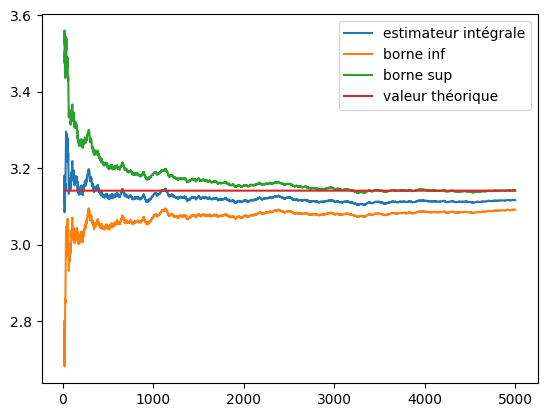

In [10]:
def g(x):
    return(4*np.sqrt(1-x**2))

def estimation_et_intervalle_integrale(N,alpha):
    S=[] #contient les estimateurs
    I1=[] #contient les bornes inf
    I2=[] #contient les bornes sup
    T=np.arange(1,N+1)
    X=stats.uniform.rvs(loc=0,scale=1,size=N)
    Y=g(X)
    for n in range(1,N+1):
        Yn=Y[:n]
        s=np.mean(Yn)
        sigma=sqrt(np.mean((Yn-s)**2))
        q=stats.norm.ppf(q=1-alpha/2,loc=0,scale=1)
        c=q*sigma/sqrt(n)
        i1=s-c
        i2=s+c
        S.append(s)
        I1.append(i1)
        I2.append(i2)
    plt.plot(T[15:],S[15:],label='estimateur intégrale') # je commence à 15 pour éviter les pics abberants des premières valeurs
    plt.plot(T[15:],I1[15:],label='borne inf')
    plt.plot(T[15:],I2[15:],label='borne sup')
    plt.plot(T[15:],pi*np.ones(len(T[15:])), label='valeur théorique')
    plt.legend()
    plt.show()

estimation_et_intervalle_integrale(5000,0.05)

Voyons un autre exemple. On souhaite cette fois calculer l'intégrale 
$$ I = \int_{\mathbb R} \cosh(x) e^{-x^2} \mathrm{d}x.$$
Si $ X \sim \mathcal N (0, \frac{1}{\sqrt 2})$, alors 
$$ \mathbb E [ \sqrt \pi \cosh X] = \int_{\mathbb R} \sqrt\pi \cosh(x) \frac{e^{-2\frac{x^2}{2}}}{\frac{1}{\sqrt 2} \sqrt{2\pi}} \mathrm{d}x = I. $$
Ainsi, pour estimer $I$, on simule un $n$-échantillon $(X_i)_{1 \le i \le n}$ de loi $\mathcal N (0, \frac{1}{\sqrt 2})$ et on calcule 
$$\frac{1}{n} \sum_{i=1}^n \sqrt \pi \cosh(X_i). $$

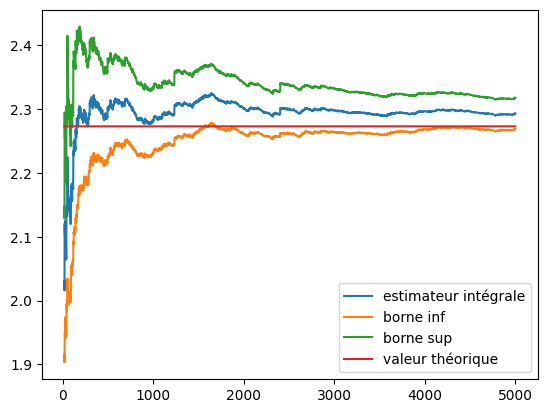

In [11]:
def h(x):
    return(sqrt(pi)*np.cosh(x))

def estimation_et_intervalle_integrale2(N,alpha):
    S=[] #contient les estimateurs
    I1=[] #contient les bornes inf
    I2=[] #contient les bornes sup
    T=np.arange(1,N+1)
    X=stats.norm.rvs(loc=0,scale=(1/sqrt(2)),size=N)
    Y=h(X)
    for n in range(1,N+1):
        Yn=Y[:n]
        s=np.mean(Yn)
        sigma=sqrt(np.mean((Yn-s)**2))
        q=stats.norm.ppf(q=1-alpha/2,loc=0,scale=1)
        c=q*sigma/sqrt(n)
        i1=s-c
        i2=s+c
        S.append(s)
        I1.append(i1)
        I2.append(i2)
    plt.plot(T[15:],S[15:],label='estimateur intégrale') # je commence à 15 pour éviter les pics abberants des premières valeurs
    plt.plot(T[15:],I1[15:],label='borne inf')
    plt.plot(T[15:],I2[15:],label='borne sup')
    plt.plot(T[15:],2.273*np.ones(len(T[15:])), label='valeur théorique')
    plt.legend()
    plt.show()

estimation_et_intervalle_integrale2(5000,0.05)

Comme on le voit sur les bornes de l'intervalle de confiance asymptotique, plus la variance de l'estimateur sera faible, meilleure sera notre estimation : il faut donc essayer de bricoler nos méthodes de Monte-Carlo pour obtenir des estimateurs à faible variance (cf TP3). Il existe des sujets de modé sur ce genre de thématiques. 